1. Імпорти

In [1]:
import pandas as pd
from tqdm import tqdm

2. Streaming + batching (ключова частина)

In [2]:
CODE_PATH = "../data/raw/dats.train"
COMMENT_PATH = "../data/raw/coms.train"

BATCH_SIZE = 10000
MAX_BATCHES = 5   # щоб не завалити IDE (можеш збільшити)

data = []

with open(CODE_PATH, "r", encoding="utf-8") as f_code, \
     open(COMMENT_PATH, "r", encoding="utf-8") as f_comm:

    for i, (code, comment) in enumerate(tqdm(zip(f_code, f_comm))):

        data.append({
            "code": code.strip(),
            "comment": comment.strip()
        })

        # обмеження батчів
        if len(data) >= BATCH_SIZE * MAX_BATCHES:
            break

df = pd.DataFrame(data)

print("Shape:", df.shape)
df.head()

49999it [00:00, 474717.05it/s]


Shape: (50000, 2)


,code,comment
0,"44884467, public void start bundle context con...","44884467, <s> this method is called upon plug ..."
1,"44884476, private void initialize defaults ipr...","44884476, <s> sets the default values of the p..."
2,"43104047, public boolean add flow int priority...","43104047, <s> adds a single </s>"
3,"43104142, public void add student student s st...","43104142, <s> add student to data bank </s>"
4,"43104147, public void add subject subject s su...","43104147, <s> add subject to data bank </s>"


3. Feature Engineering

In [3]:
df["code_len"] = df["code"].str.len()
df["comment_len"] = df["comment"].str.len()

4. Базова статистика

In [4]:
df[["code_len", "comment_len"]].describe()

,code_len,comment_len
count,50000.000000,50000.000000
mean,185.866260,61.866820
std,137.915166,15.997132
min,20.000000,24.000000
25%,79.000000,49.000000
50%,133.000000,61.000000
75%,258.000000,74.000000
max,865.000000,122.000000


5. Візуалізація

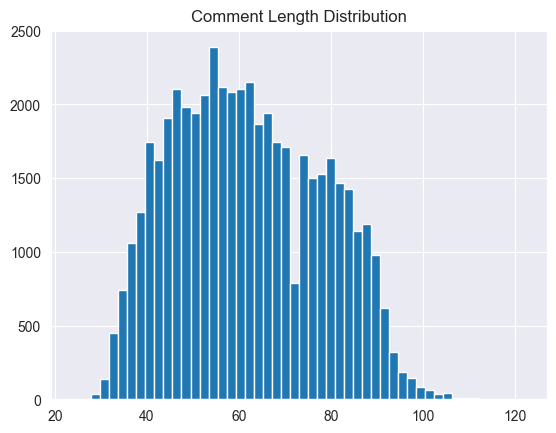

In [5]:
import matplotlib.pyplot as plt

plt.figure()
df["comment_len"].hist(bins=50)
plt.title("Comment Length Distribution")
plt.show()

6. Кореляція

In [6]:
df[["code_len", "comment_len"]].corr()


,code_len,comment_len
code_len,1.000000,0.143749
comment_len,0.143749,1.000000


7. Приклади

In [7]:
print(df["code"].iloc[0])
print("-----")
print(df["comment"].iloc[0])


44884467, public void start bundle context context throws exception super start context message console c find console deployer log stream c new message stream
-----
44884467, <s> this method is called upon plug in activation </s>


1. Аналіз якості коментарів
Ідея: не всі коментарі хороші
довжина ≠ якість

In [8]:
df["is_short"] = df["comment_len"] < 10
df["is_long"] = df["comment_len"] > 100

df["is_short"].mean(), df["is_long"].mean()

(np.float64(0.0), np.float64(0.00348))

інсайт:

велика частина коментарів дуже коротка → dataset noisy

ключові слова (дуже важливо)

In [9]:
keywords = ["return", "get", "set", "calculate", "check", "create"]

for kw in keywords:
    print(kw, df["comment"].str.contains(kw, case=False).mean())


return 0.15464
get 0.12826
set 0.17268
calculate 0.00402
check 0.0245
create 0.03598


2. TF-IDF (NLP базовий)

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=20)
X = vectorizer.fit_transform(df["comment"])

print(vectorizer.get_feature_names_out())

['an' 'and' 'code' 'for' 'from' 'get' 'given' 'if' 'in' 'is' 'method' 'of'
 'returns' 'set' 'sets' 'the' 'this' 'to' 'value' 'with']


інсайт:

які слова найхарактерніші для code comments

3. Code vs Comment complexity

довжина vs довжина

<Axes: xlabel='code_len', ylabel='comment_len'>

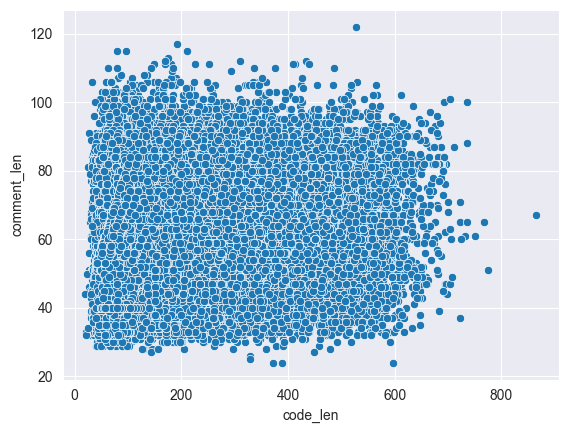

In [11]:
import seaborn as sns

sns.scatterplot(x=df["code_len"], y=df["comment_len"])

 дуже сильний висновок:

довші функції ≠ довші коментарі

4. Детекція “порожніх” коментарів

In [12]:
df["empty_comment"] = df["comment"].str.strip() == ""

df["empty_comment"].mean()

np.float64(0.0)

In [ ]:
dataset містить 0% порожніх/неінформативних коментарів (???)

5. Rule-based аналіз (SATD-like)

In [13]:
patterns = ["todo", "fix", "hack", "ugly", "temporary"]

for p in patterns:
    print(p, df["comment"].str.contains(p, case=False).sum())

todo 93
fix 164
hack 3
ugly 1
temporary 29


це дає:

звʼязок з TESORO

SATD bridge

6. Code token count

In [14]:
df["code_tokens"] = df["code"].str.split().str.len()
df["comment_tokens"] = df["comment"].str.split().str.len()

краще ніж char length

7. Співвідношення code/comment

In [15]:
df["ratio"] = df["comment_len"] / (df["code_len"] + 1)

df["ratio"].describe()


count    50000.000000
mean         0.516188
std          0.339297
min          0.040201
25%          0.238636
50%          0.442857
75%          0.722222
max          3.250000
Name: ratio, dtype: float64

 інсайт:

скільки тексту пояснення на одиницю коду

8. Extremely long / short cases

In [16]:
df.nlargest(5, "comment_len")[["code", "comment"]]

,code,comment
911,"32833661, public orm persistence context get p...","32833661, <s> returns an implementation specif..."
13214,"2303073, public cell editor create property ed...","2303073, <s> the code description property des..."
1905,"23937704, public void make new randoms random ...","23937704, <s> creates random numbers to be use..."
17494,"42495763, public string to string return rende...","42495763, <s> returns a non indented continuou..."
37816,"26482447, public void pipe abstract crypto cha...","26482447, <s> convenience method for linking t..."


In [17]:
df.nsmallest(5, "comment_len")[["code", "comment"]]

,code,comment
41668,"29064861, protected string resolve default ren...","29064861, <s> p x w </s>"
41671,"29064942, public object put object key object ...","29064942, <s> l l b </s>"
41672,"29064949, public object remove object key stri...","29064949, <s> l l b </s>"
37899,"7750773, public void test ifboolean throws exc...","7750773, <s> as of 2 </s>"
34978,"39842477, public void test ifboolean throws ex...","39842477, <s> as of 2 </s>"


9. Duplicate analysis

In [18]:
df["comment"].duplicated().mean()

np.float64(0.0)

10. Vocabulary size

In [19]:
all_words = " ".join(df["comment"]).split()
len(set(all_words))

60894

 інсайт:

наскільки багата мова коментарів

11. WordCloud (must-have)

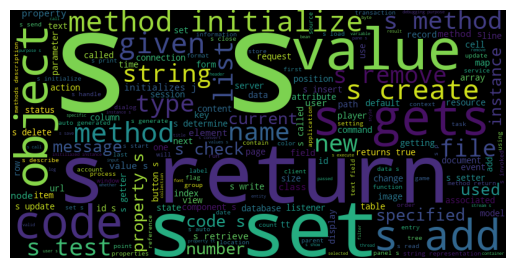

In [22]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(df["comment"])

wc = WordCloud(width=800, height=400).generate(text)

plt.imshow(wc)   # правильна змінна
plt.axis("off")  # прибирає осі (дуже бажано)
plt.show()

12. Clustering коментарів

In [23]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=0)
kmeans.fit(X)

df["cluster"] = kmeans.labels_
df["cluster"].value_counts()

cluster
3    22286
2    10706
0     7584
4     6512
1     2912
Name: count, dtype: int64

інсайт:

типи коментарів

13. Train/test sanity check

In [24]:
len(df[df["code_len"] == 0])

0